# 运行环境导入

In [3]:
# 启用自动重载扩展，使得在修改Python模块后不需要重启内核就能使用最新的代码
%load_ext autoreload

# 设置自动重载模式为2，表示所有模块都会被自动重载
# 这在开发过程中非常有用，因为不需要手动重启kernel来应用代码更改
%autoreload 2

import torch
from shepherd.lightning_module import LightningModule

import pickle

import rdkit
import numpy as np

from shepherd.shepherd_score_utils.conformer_generation import update_mol_coordinates

from shepherd.shepherd_score_utils.generate_point_cloud import (
    get_atomic_vdw_radii, 
    get_molecular_surface,
    get_electrostatics_given_point_charges,
)
from shepherd.shepherd_score_utils.pharm_utils.pharmacophore import get_pharmacophores

from tqdm import tqdm
from shepherd.shepherd_score_utils.pharm_utils.pharmacophore import get_pharmacophores

import json
import numpy as np

from shepherd.inference import *
import os

from shepherd.extract import create_rdkit_molecule

import json
import numpy as np

import json
import numpy as np
import torch  # 导入 torch 库，因为我们需要处理 Tensor 类型

os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

from shepherd_score.evaluations.evaluate import ConfEval, UnconditionalEvalPipeline
from shepherd_score.evaluations.evaluate import ConsistencyEvalPipeline, ConditionalEvalPipeline

from shepherd_score.container import Molecule



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 模型参数、sample参考分子 加载

In [ ]:
# 配置

chkpt = '/home1/zhh/workspace/SPD/checkpoint/last.ckpt'
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model_pl = LightningModule.load_from_checkpoint(chkpt) #
params = model_pl.params
model_pl.to(device)
model_pl.model.device = device


with open('/home1/zhh/workspace/SPD/data/conformers/np/molblock_charges_NPs.pkl', 'rb') as f:
    # 从pkl文件中读取molblock和charges数据
    molblocks_and_charges = pickle.load(f)
    # 打印数据长度以确认实际包含的分子数量
    print(f"加载的数据包含 {len(molblocks_and_charges)} 个分子")

# 选择要处理的天然产物分子的索引，只有第一个
index = 0 # 0, 1, 2

# 从molblock创建RDKit分子对象,保留氢原子
mol = rdkit.Chem.MolFromMolBlock(molblocks_and_charges[index][0], removeHs = False) # target natural product
# 获取分子的隐式水环境下的xTB部分电荷
charges = np.array(molblocks_and_charges[index][1]) # xTB partial charges in implicit water
# 使用display函数显示RDKit分子对象mol的2D结构图
display(mol)
# 返回是 <rdkit.Chem.rdchem.Mol at 0x7f3412458cf0> 表示一个RDKit分子对象的内存地址信息

/home1/zhh/workspace/SPD/.venv/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v2.5.2


正在以非严格模式加载模型状态，将忽略检查点中不匹配的键...


# 数据预处理

In [ ]:
# 分子坐标标准化算法
# 步骤1：提取原始3D坐标矩阵 (N×3，N为原子数)
mol_coordinates = np.array(mol.GetConformer().GetPositions())

# 步骤2：计算几何中心并进行中心化处理
# 目的：消除分子在空间中的绝对位置影响，只保留相对几何结构
mol_coordinates = mol_coordinates - np.mean(mol_coordinates, axis = 0)

# 步骤3：更新分子对象的坐标信息
# 功能：将标准化后的坐标重新写入RDKit分子对象
mol = update_mol_coordinates(mol, mol_coordinates)

# 条件特征提取算法工作流程
# 步骤1：提取原子几何信息
# 功能：获取所有原子的三维坐标作为几何基础
centers = mol.GetConformer().GetPositions()
print("原子中心坐标 centers shape:", centers.shape)

# 步骤2：计算原子范德华半径
# 功能：获取每个原子的范德华半径，用于分子表面计算
radii = get_atomic_vdw_radii(mol)
print("范德华半径 radii shape:", radii.shape)

# 步骤3：生成分子表面点云 (x3模态)
# 算法：基于原子坐标和范德华半径，使用探针球滚动算法生成分子可及表面
# 参数：num_points控制表面点密度，probe_radius为探针半径，num_samples_per_atom为每原子采样数
surface = get_molecular_surface(
    centers, 
    radii, 
    params['dataset']['x3']['num_points'], # 表面点数量
    probe_radius = params['dataset']['probe_radius'], # 探针半径
    num_samples_per_atom = 20, # 每个原子的采样点数
)
print("分子表面点 surface shape:", surface.shape)

print("分子表面点 surface shape:", surface)

# 步骤4：提取药效团特征 (x4模态)
# 算法：基于RDKit的药效团识别算法，提取氢键供体/受体、疏水区域等特征
# 输出：药效团类型、三维位置坐标和方向向量
pharm_types, pharm_pos, pharm_direction = get_pharmacophores(
    mol,
    multi_vector = params['dataset']['x4']['multivectors'], # 是否使用多向量表示
    check_access = params['dataset']['x4']['check_accessibility'], # 是否检查可及性
)
print("药效团类型 pharm_types:", pharm_types.shape)
print("药效团位置 pharm_pos shape:", pharm_pos.shape)
print("药效团方向 pharm_direction shape:", pharm_direction.shape)

# 步骤5：计算表面静电势分布
# 算法：基于库仑定律，使用原子部分电荷计算表面各点的静电势值
# 公式：V(r) = Σ(qi / |r - ri|)，其中qi为原子电荷，ri为原子位置
electrostatics = get_electrostatics_given_point_charges(
    charges, centers, surface,
)
print("静电势 electrostatics shape:", electrostatics.shape)



# 计算数据集的边际分布

In [15]:
# ===== 数据集边际分布统计算法 =====
# 算法核心思想：统计训练数据中各类特征的出现频率，为生成模型提供先验分布
# 实现原理：
# 1. 特征类型定义：基于化学知识定义原子类型、键类型和药效团类型
# 2. 频率统计：遍历数据集统计每种特征类型的出现次数
# 3. 概率分布：将计数转换为概率分布，指导生成过程的采样
# 4. 先验知识：为扩散模型提供化学合理的特征分布先验


print("初始化用于统计各类特征出现次数的计数器")

# 边际分布计算的特征类型定义
# 数据来源：training/parameters/params_x1x3x4_diffusion_mosesaq_20240824.py

# 原子类型定义 (x1模态)
# 包含常见的有机分子原子类型，None表示空位或填充
atom_types_x1 = [None, 'H', 'C', 'N', 'O', 'F', 'Cl', 'Br', 'I', 'S', 'P', 'Si']

# 化学键类型定义 (x1模态)
# 涵盖所有主要的化学键类型，用于分子图表示
bond_types_x1 = [None, 'SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC']

# 药效团类型最大数量 (x4模态)
# 定义药效团特征的维度上限
max_node_types_x4 = 10

# 初始化特征计数器
# 算法：使用torch.zeros创建计数张量，便于后续的GPU加速计算
# 数据类型：float类型支持概率计算和梯度传播
atom_counts = torch.zeros(len(atom_types_x1), dtype=torch.float)
bond_counts = torch.zeros(len(bond_types_x1), dtype=torch.float)
pharm_counts = torch.zeros(max_node_types_x4, dtype=torch.float)

# 化学键类型映射函数
# 功能：将RDKit的键类型对象转换为参数文件中使用的字符串表示
def get_bond_type_str(bond):
    return str(bond.GetBondType())

# 边际分布统计主循环
# 算法流程：遍历整个数据集，统计各类特征的出现次数
for mol_block, _ in tqdm(molblocks_and_charges, desc="Counting feature occurrences"):
    # 步骤1：从MolBlock字符串创建RDKit分子对象
    # 保留氢原子：removeHs=False确保统计包含所有原子类型
    mol = rdkit.Chem.MolFromMolBlock(mol_block, removeHs=False)
    if not mol:
        print("Warning: Failed to create molecule from MolBlock. 跳过了奥.")
        continue
    
    # 步骤2：统计原子类型出现次数
    # 遍历分子中的每个原子，累加对应类型的计数
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in atom_types_x1:
            atom_counts[atom_types_x1.index(symbol)] += 1

    # 步骤3：统计化学键类型出现次数
    # 遍历分子中的每个化学键，累加对应类型的计数
    for bond in mol.GetBonds():
        bond_str = get_bond_type_str(bond)
        if bond_str in bond_types_x1:
            bond_counts[bond_types_x1.index(bond_str)] += 1
     
    try:
        # 步骤4：统计药效团类型出现次数
        # 算法：使用RDKit的药效团识别功能提取分子的药效团特征
        pharm_types_temp, _, _ = get_pharmacophores(
            mol, 
            multi_vector=False,  # 不使用多向量表示
            check_access=False   # 不检查可及性
        ) 
        # 索引偏移处理：数据集代码为每个药效团类型加1，为虚拟节点预留索引0
        # 必须复制此逻辑以确保计数的准确性
        for p_type in (pharm_types_temp + 1):
            if p_type < max_node_types_x4:
                pharm_counts[p_type] += 1
    except Exception as e:
        # This can happen for molecules that don't have RDKit's feature definitions
        print(f"Warning: Could not get pharmacophores for a molecule. Skipping. Error: {e}")

# --- 3. Normalize counts to get probabilities (marginals) ---

# Handle the case where a feature type might have zero counts to avoid division by zero


atom_marginals_x1 = (atom_counts / atom_counts.sum()) if atom_counts.sum() > 0 else torch.ones_like(atom_counts) / len(atom_counts)
bond_marginals_x1 = (bond_counts / bond_counts.sum()) if bond_counts.sum() > 0 else torch.ones_like(bond_counts) / len(bond_counts)
pharm_marginals_x4 = (pharm_counts / pharm_counts.sum()) if pharm_counts.sum() > 0 else torch.ones_like(pharm_counts) / len(pharm_counts)

print("\n--- 边际分布 计算完毕 ---")
print(f"Atom Marginals (x1): {atom_marginals_x1.shape}")
print(f"Bond Marginals (x1): {bond_marginals_x1.shape}")
print(f"Pharmacophore Marginals (x4): {pharm_marginals_x4.shape}")
print("---------------------------------------\n")


初始化用于统计各类特征出现次数的计数器


Counting feature occurrences: 100%|██████████| 3/3 [00:00<00:00, 87.95it/s]


--- 边际分布 计算完毕 ---
Atom Marginals (x1): torch.Size([12])
Bond Marginals (x1): torch.Size([5])
Pharmacophore Marginals (x4): torch.Size([10])
---------------------------------------



#  Sample 参数配置

In [17]:
# ===== 条件生成模型配置参数 =====
# 算法核心：控制条件分子生成过程的关键超参数设置
# 实现原理：
# 1. 分子规模控制：通过n_atoms限制生成分子的复杂度和计算开销
# 2. 并行处理优化：通过batch_size平衡内存使用和生成效率
# 3. 条件约束匹配：确保药效团数量与条件输入的维度一致性

# 参数1：目标分子原子数量
# 功能：定义生成分子的最大原子数，影响分子复杂度和生成质量
# 取值范围：通常10-100，根据目标分子类型调整
n_atoms = 70

# 参数2：批处理大小
# 功能：控制同时生成的分子数量，影响内存占用和计算效率
# 优化策略：根据GPU内存容量和生成速度需求平衡设置
batch_size = 5

# 参数3：药效团特征维度
# 算法约束：在条件生成(inpainting)模式下，药效团数量必须与输入条件的药效团位置数量严格匹配
# 数据一致性：确保pharm_types长度等于pharm_pos.shape[0]，维持条件-生成的对应关系
num_pharmacophores = len(pharm_types) # must equal pharm_pos.shape[0] if inpainting

# Conditional Sampling and Store output

In [ ]:
# ===== 条件分子生成推理算法 =====
# 算法核心思想：基于扩散模型的条件分子生成，固定x2(表面)和x3(静电势)条件，生成x1(原子图)和x4(药效团)
# 实现原理：
# 1. 扩散过程：从噪声开始，通过逐步去噪生成目标分子结构
# 2. 条件约束：在生成过程中保持指定条件不变，确保生成结果符合约束
# 3. 多模态融合：同时处理原子图、表面、静电势和药效团四种模态
# 4. 修复机制：通过inpainting技术精确控制各模态的生成行为


# 条件分子生成主函数调用
# 算法：使用训练好的扩散模型进行条件生成推理
# 调用推理采样函数并将结果保存到文件
generated_samples = inference_sample(
    model_pl,  # 预训练的扩散模型对象
    batch_size = batch_size,  # 批处理大小，控制并行生成数量
    
    # 生成目标的维度控制
    N_x1 = n_atoms,  # x1模态：目标分子的原子数量
    N_x4 = num_pharmacophores,  # x4模态：目标分子的药效团数量
    
    # 生成模式配置
    unconditional = False,  # 条件生成模式：False表示基于给定条件生成
    
    # 噪声控制参数
    # 算法：控制扩散过程中的噪声强度，影响生成质量和多样性
    prior_noise_scale = 1.0,  # 先验噪声缩放：控制初始噪声强度
    denoising_noise_scale = 1.0,  # 去噪噪声缩放：控制去噪过程的噪声水平
    
    # 动态噪声注入机制
    # 功能：在特定时间步注入额外噪声，增加生成多样性
    inject_noise_at_ts = [],  # 噪声注入时间步列表（空表示不注入）
    inject_noise_scales = [],  # 对应的噪声强度列表
    
    # 谐波化处理参数
    # 算法：通过谐波化技术优化生成轨迹，提高生成质量
    harmonize = False,  # 谐波化开关：False表示不启用
    harmonize_ts = [],  # 谐波化时间步列表
    harmonize_jumps = [],  # 谐波化跳跃步长列表
    
    # ===== 条件修复(Inpainting)参数配置 =====
    # 核心机制：精确控制各模态在生成过程中的行为
    
    # x2模态修复配置（原子位置，通过x3隐式建模）
    inpaint_x2_pos = False,  # 不修复x2位置：作为固定条件
    
    # x3模态修复配置（分子表面和静电势）
    inpaint_x3_pos = False,  # 不修复x3位置：作为固定条件输入
    inpaint_x3_x = False,  # 不修复x3特征：保持表面和静电势不变
    
    # x4模态修复配置（药效团特征）
    # 策略：完全修复x4，使其与生成的x1原子图保持一致
    inpaint_x4_pos = True,  # 修复药效团位置：确保空间一致性
    inpaint_x4_direction = True,  # 修复药效团方向：确保方向一致性
    inpaint_x4_type = True,  # 修复药效团类型：确保类型一致性
    
    # ===== 修复过程的时间和噪声控制 =====
    # 算法：通过时间控制和噪声调节优化修复效果
    
    # x2修复时间控制
    stop_inpainting_at_time_x2 = 0.0,  # x2停止修复时间：0.0表示全程修复
    add_noise_to_inpainted_x2_pos = 0.0,  # x2修复噪声：0.0表示无额外噪声
    
    # x3修复时间控制
    stop_inpainting_at_time_x3 = 0.0,  # x3停止修复时间：0.0表示全程修复
    add_noise_to_inpainted_x3_pos = 0.0,  # x3位置修复噪声
    add_noise_to_inpainted_x3_x = 0.0,  # x3特征修复噪声
    
    # x4修复时间控制
    # 策略：全程修复x4各属性，确保与生成的x1完全匹配
    stop_inpainting_at_time_x4 = 0.0,  # x4停止修复时间：0.0表示全程修复
    add_noise_to_inpainted_x4_pos = 0.0,  # x4位置修复噪声：0.0确保精确匹配
    add_noise_to_inpainted_x4_direction = 0.0,  # x4方向修复噪声：0.0确保精确匹配
    add_noise_to_inpainted_x4_type = 0.0,  # x4类型修复噪声：0.0确保精确匹配
    
    # 条件输入数据
    center_of_mass = np.zeros(3),  # x1的质心(已经中心化为零)
    surface = surface,  # 表面特征 x2
    electrostatics = electrostatics,  # 静电特征 x3
    pharm_types = pharm_types,  # 药效团类型 x3
    pharm_pos = pharm_pos,  # 药效团位置
    pharm_direction = pharm_direction,  # 药效团方向

    atom_marginals=atom_marginals_x1,
    bond_marginals=bond_marginals_x1,
)


def convert_for_json(obj):
    """
    功能说明：递归地将一个复杂的数据结构（可能包含字典、列表、numpy数组和torch张量）
              转换为能够被JSON库序列化的纯Python数据结构（只包含字典、列表、字符串、数字等）。
    参数解释：
        obj: 可能是字典、列表、numpy数组、torch张量等任意类型的对象。
    实现逻辑：
        - 如果对象是字典，就递归地转换它的每一个值。
        - 如果对象是列表，就递归地转换它的每一个元素。
        - 如果对象是numpy数组，就使用 .tolist() 方法将其转换为Python列表。
        - 如果对象是torch张量，先用 .cpu() 把它从GPU（如果有的话）移到CPU，
          再用 .numpy() 转成numpy数组，最后用 .tolist() 转成Python列表。
        - 其他类型的对象直接返回。
    注意事项：这个函数假设 torch 库已经安装并可以导入。
    """
    if isinstance(obj, dict):
        return {k: convert_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [convert_for_json(elem) for elem in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.cpu().numpy().tolist()
    return obj

# 假设 generated_samples 是你已经生成好的数据
# 1. 先使用我们新的辅助函数来转换数据
generated_samples_for_json = convert_for_json(generated_samples)

# 2. 保存到 JSON 文件
# 我们把文件名改成 output.json
with open('output.json', 'w', encoding='utf-8') as f:
    # 使用 json.dump 来写入文件
    # indent=4 会让文件内容格式化，看起来更整齐，方便阅读
    json.dump(generated_samples_for_json, f, ensure_ascii=False, indent=4)

print("数据已成功保存到 output.json 文件！")

Initialized DiscreteFeatureDiffusion with marginals: tensor([0.0000, 0.4742, 0.3944, 0.0047, 0.1268, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])
Initialized DiscreteFeatureDiffusion with marginals: tensor([0.0000, 0.8705, 0.0804, 0.0000, 0.0491])


100%|██████████| 400/400 [07:49<00:00,  1.17s/it]


数据已成功保存到 output.json 文件！


# 加载上一次生成的分子

In [20]:

# 从 JSON 文件读取数据
with open('output.json', 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

# 现在 loaded_data 的结构和你的 generated_samples 一样，
# 只是里面都是 Python 列表而不是 numpy 数组。
# 我们可以写一个循环把它转换回来。

reloaded_samples = []
for sample in loaded_data:
    # 遍历 'x1', 'x2', 'x3', 'x4' 等模态
    for modal_key in sample:
        # 遍历 'atoms', 'bonds', 'positions' 等数据
        for data_key in sample[modal_key]:
            # 把列表转换回 numpy 数组
            if isinstance(sample[modal_key][data_key], list):
                sample[modal_key][data_key] = np.array(sample[modal_key][data_key])
    reloaded_samples.append(sample)


print("从 output.json 文件中成功读取并恢复了数据！")



从 output.json 文件中成功读取并恢复了数据！


# 评估管道

## 测试评估 提取能力、采样结果 是否正常

atoms: [ 6  6  6  6  6  6 17  6  6  6  8  6  6  6  6  7  7  7  6  6  6  6  6 17  6  6  6  8  6  6  6  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
positions: [[-3.53247021 -1.38821552  1.03613928]
 [-4.77929976 -0.7130674   1.50840086]
 [-5.18129679  0.49265928  0.704925  ]
 [-6.33088722  1.21108405  1.07085532]
 [-6.72642027  2.33383399  0.34128229]
 [-5.97678781  2.74595766 -0.75808458]
 [-6.4696014   4.12960854 -1.65386231]
 [-4.8347151   2.04615718 -1.13551115]
 [-4.43612141  0.91891192 -0.40396596]
 [-3.21611913  0.18719346 -0.82619804]
 [-2.58385726  0.55585286 -1.8105045 ]
 [-2.79995756 -1.00378011 -0.0230815 ]
 [-1.5758369  -1.7496914  -0.36394876]
 [-0.31620099 -1.14691286 -0.19308181]
 [ 0.87481453 -1.82311025 -0.50202647]
 [ 2.17425793 -1.22338822 -0.33654666]
 [ 3.19171974 -1.95438069 -0.9021232 ]
 [ 4.38282874 -1.58511491 -0.88640188]
 [ 4.72173813 -0.36750336 -0.29862805]
 [ 6.05877874  0.05114941 -0.3358658 ]
 [ 6.46548565  1.26538879  0.24640215]
 [ 7.91151196  1.670604

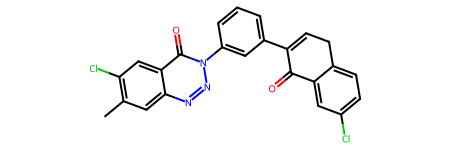

In [ ]:
# 加载 ground-truth 测试功能 -- 结果 extract管线正常

from shepherd.extract import create_rdkit_molecule_from_mol
from shepherd_score.conformer_generation import embed_conformer_from_smiles

rdkit_mol = embed_conformer_from_smiles('c1Cc2ccc(Cl)cc2C(=O)c1c3cc(N1nnc2cc(C)c(Cl)cc2c1=O)ccc3', MMFF_optimize=True)

# 提取原子序数数组 - 每个原子的原子序数（如C=6, N=7, O=8, Cl=17等）
atoms = np.array([a.GetAtomicNum() for a in rdkit_mol.GetAtoms()])
# 获取原子的三维坐标位置矩阵 (N_atoms × 3)
positions = rdkit_mol.GetConformer().GetPositions()

# print("atoms:", atoms)
# print("positions:", positions)

mol_ = create_rdkit_molecule_from_mol(atoms, positions)

display(rdkit.Chem.MolFromSmiles(rdkit.Chem.MolToSmiles(mol_)))

for b, sample_dict in enumerate(reloaded_samples):

    mol_ = create_rdkit_molecule(sample_dict)

    if mol_ is None:
        continue

    display(rdkit.Chem.MolFromSmiles(rdkit.Chem.MolToSmiles(mol_)))

## 使用ConfEval进行评估

In [ ]:
# 从生成的结构中提取原子和位置信息进行构象评估
evaluation_results = []  # 存储所有评估结果

for i, structure in enumerate(reloaded_samples):
    print(f"正在评估第 {i+1}/{len(reloaded_samples)} 个生成结构...")
    
    try:
        # 从 X1 模态中提取原子信息和位置坐标

        # print("atoms_onehot:", atoms_onehot)

        positions = structure['x1']['positions']  # 原子三维坐标位置

        atoms = structure['x1']['atoms']  # 原子类型（原子序数）

        print("atoms_shape:", atoms.shape)

        # 数据预处理：确保数据格式正确
        if isinstance(atoms, np.ndarray):
            atoms = atoms.flatten()  # 展平为一维数组
        if isinstance(positions, np.ndarray) and positions.ndim == 2:
            # 确保位置坐标是 (N_atoms, 3) 的形状
            if positions.shape[1] != 3:
                print(f"警告：第 {i+1} 个结构的位置坐标维度不正确: {positions.shape}")
                continue
        
        if len(atoms) == 0:
            print(f"警告：第 {i+1} 个结构没有有效原子，跳过评估")
            continue
            
        print(f"  - 原子数量: {len(atoms)}")
        print(f"  - 位置坐标形状: {positions.shape}")
        
        # 使用 ConfEval 进行构象评估
        conf_eval = ConfEval(atoms, positions, solvent='water')
        
        # 获取评估结果
        eval_df = conf_eval.to_pandas()

        print("评估结果是：", eval_df)
        
        # 存储评估结果
        result_dict = {
            'structure_id': i,
            'num_atoms': len(atoms),
            'evaluation_data': eval_df,
            'atoms': atoms,
            'positions': positions,
            'x4_positions': structure['x4']['positions'],  # 同时保存X4位置用于RMSD计算
            'x4_types': structure['x4']['types'],  # 药效团类型
        }
        
        evaluation_results.append(result_dict)
        print(f"  ✓ 第 {i+1} 个结构评估完成")
        
    except Exception as e:
        print(f"  ✗ 第 {i+1} 个结构评估失败: {str(e)}")
        continue

print(f"\n总共成功评估了 {len(evaluation_results)} 个结构")

正在评估第 1/5 个生成结构...
atoms_shape: (70,)
  - 原子数量: 70
  - 位置坐标形状: (70, 3)
评估结果是： xyz_block                   70\n\nH      3.75863719     -0.12833354      1...
mol                          <rdkit.Chem.rdchem.Mol object at 0x7fe86f0fcba0>
smiles                      CCC(CC)(CCO)[C@H](O)NC(=O)N(CCCO)CC(=O)C[C@]1(...
molblock                    \n     RDKit          3D\n\n 70 70  0  0  0  0...
energy                                                             -98.831477
partial_charges             [-0.00587862, 0.04977577, 0.03587105, 0.047028...
solvent                                                                 water
charge                                                                     -1
xyz_block_post_opt          70\n\nH            3.54137019293007       -0.3...
mol_post_opt                 <rdkit.Chem.rdchem.Mol object at 0x7fe864f07dd0>
smiles_post_opt             CCC(CC)(CCO)[C@H](O)NC(=O)N(CCCO)CC(=O)C[C@]1(...
molblock_post_opt           \n     RDKit          3D\n\n 70 70  

## 使用UnconditionalEvalPipeline进行评估

In [ ]:
from shepherd_score.evaluations.evaluate import UnconditionalEvalPipeline

generated_mols = []

for b, sample_dict in enumerate(reloaded_samples):

    print(sample_dict)

    mol_ = create_rdkit_molecule(sample_dict)

    if mol_ is None:
        continue

    atoms_array = np.array([a.GetAtomicNum() for a in mol_.GetAtoms()])
    
    # positions_matrix: 二维numpy数组，形状为(n_atoms, 3)
    #   - 包含每个原子的3D坐标(x, y, z)，单位为埃(Å)
    positions_matrix = mol_.GetConformer().GetPositions()
    
    # 将原子信息和坐标信息打包为元组，添加到生成分子列表
    generated_mols.append((atoms_array, positions_matrix))

uncond_pipe = UnconditionalEvalPipeline(generated_mols=generated_mols, solvent='water')

uncond_pipe.evaluate(verbose=True)

properties_df, global_attr = uncond_pipe.to_pandas()

{'x1': {'atoms': array([ 8,  1,  6,  7, 35,  8,  8,  7, 16,  6]), 'bonds': array([0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 4, 1, 0, 2, 0, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0]), 'positions': array([[ 0.73074704,  0.05488776, -2.32279968],
       [ 0.53879815,  0.23667921,  2.24072933],
       [ 0.41975436,  0.01419125, -1.23125005],
       [-0.99314445, -0.18651202,  0.75475872],
       [ 2.88404822,  0.72225559,  0.25522068],
       [-1.82564712, -0.19340844,  1.55324495],
       [-1.97150338, -0.65240663, -1.58377123],
       [ 0.25950369,  0.1404119 ,  1.10150909],
       [-1.13750839, -0.38088799, -0.81038779],
       [ 1.0949707 ,  0.24476573,  0.04291318]])}, 'x2': {'positions': array([[ 0.        ,  0.        ,  0.        ],
       [-0.90080482, -5.40817014, -3.11789042],
       [-2.88204787, -5.38464477, -0.52175388],
       [-6.33457505,  2.41184018,  0.70305489],
       [ 5.15401464,  0.26773005, -3.55392565],
       [ 2.42639204, -5.1

Unconditional Eval: 100%|██████████| 1/1 [00:00<00:00,  1.51it/s]

properties_df: num_generated_mols             1
solvent                    water
num_valid                      1
num_valid_post_opt             1
num_consistent_graph           0
frac_valid                   1.0
frac_valid_post_opt          1.0
frac_consistent              0.0
frac_unique                  1.0
frac_unique_post_opt         1.0
avg_graph_diversity         None
graph_similarity_matrix     None
dtype: object
global_attr:                                       generated_mols  \
0  ([8, 1, 6, 7, 35, 8, 8, 7, 16, 6], [[0.731, 0....   

                                           molblocks  \
0  \n     RDKit          3D\n\n 10 10  0  0  0  0...   

                                  molblocks_post_opt  strain_energies  rmsds  \
0  \n     RDKit          3D\n\n 10 10  0  0  0  0...         0.269765    NaN   

   SA_scores   logPs      QEDs  fsp3s  SA_scores_post_opt  logPs_post_opt  \
0   6.647898 -0.5016  0.544232    0.0            6.647898         -0.5016   

   QEDs_post_opt  fs

In [21]:
print("properties_df:", properties_df)

properties_df: num_generated_mols             1
solvent                    water
num_valid                      1
num_valid_post_opt             1
num_consistent_graph           0
frac_valid                   1.0
frac_valid_post_opt          1.0
frac_consistent              0.0
frac_unique                  1.0
frac_unique_post_opt         1.0
avg_graph_diversity         None
graph_similarity_matrix     None
dtype: object


In [22]:
print("global_attr:", global_attr)

global_attr:                                       generated_mols  \
0  ([8, 1, 6, 7, 35, 8, 8, 7, 16, 6], [[0.731, 0....   

                                           molblocks  \
0  \n     RDKit          3D\n\n 10 10  0  0  0  0...   

                                  molblocks_post_opt  strain_energies  rmsds  \
0  \n     RDKit          3D\n\n 10 10  0  0  0  0...         0.269765    NaN   

   SA_scores   logPs      QEDs  fsp3s  SA_scores_post_opt  logPs_post_opt  \
0   6.647898 -0.5016  0.544232    0.0            6.647898         -0.5016   

   QEDs_post_opt  fsp3s_post_opt  
0       0.544232             0.0  


## 使用ConsistencyEvalPipeline评估分子相似性

In [38]:
generated_mols = []           # 模态1：分子的原子序数和坐标（结构信息）
generated_surf_points = []    # 模态2：分子表面点坐标（几何信息）
generated_surf_esp = []       # 模态3：分子表面静电势（电子信息）
generated_pharm_feats = []    # 模态4：药效团特征（功能信息）

for b, sample_dict in enumerate(reloaded_samples):

    print(sample_dict)

    m = create_rdkit_molecule(sample_dict)

    if m is None:
        continue

    generated_mols.append(
    (np.array([a.GetAtomicNum() for a in m.GetAtoms()]), m.GetConformer().GetPositions())
    )

    molec = Molecule(
        m, 
        num_surf_points=200,        # 表面采样点数量（影响精度和计算成本）
        probe_radius=1.2,           # 溶剂探针半径(Å)，模拟水分子大小
        partial_charges=None,       # 使用默认MMFF94电荷计算方法
        pharm_multi_vector=False    # 药效团单向量模式（简化表示）
    )
    
    # 步骤3：提取并存储多模态特征
    # 几何模态：表面点的三维坐标
    generated_surf_points.append(molec.surf_pos)    # shape: (200, 3)
    
    # 电子模态：表面点的静电势值
    generated_surf_esp.append(molec.surf_esp)       # shape: (200,)
    
    # 功能模态：药效团特征的完整描述
    # pharm_types: 药效团类型（氢键供体、受体、疏水等）
    # pharm_ancs: 药效团锚点坐标
    # pharm_vecs: 药效团方向向量
    generated_pharm_feats.append(
        (molec.pharm_types, molec.pharm_ancs, molec.pharm_vecs)
    )
    


{'x1': {'atoms': array([ 8,  1,  6,  7, 35,  8,  8,  7, 16,  6]), 'bonds': array([0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 4, 1, 0, 2, 0, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 4, 0]), 'positions': array([[ 0.73074704,  0.05488776, -2.32279968],
       [ 0.53879815,  0.23667921,  2.24072933],
       [ 0.41975436,  0.01419125, -1.23125005],
       [-0.99314445, -0.18651202,  0.75475872],
       [ 2.88404822,  0.72225559,  0.25522068],
       [-1.82564712, -0.19340844,  1.55324495],
       [-1.97150338, -0.65240663, -1.58377123],
       [ 0.25950369,  0.1404119 ,  1.10150909],
       [-1.13750839, -0.38088799, -0.81038779],
       [ 1.0949707 ,  0.24476573,  0.04291318]])}, 'x2': {'positions': array([[ 0.        ,  0.        ,  0.        ],
       [-0.90080482, -5.40817014, -3.11789042],
       [-2.88204787, -5.38464477, -0.52175388],
       [-6.33457505,  2.41184018,  0.70305489],
       [ 5.15401464,  0.26773005, -3.55392565],
       [ 2.42639204, -5.1

In [39]:
# ==================== 一致性评估管道核心算法 ====================
# ConsistencyEvalPipeline实现了多模态分子表示的一致性验证算法
# 
# 算法原理：
# 1. 双重计算验证：对同一分子使用不同方法计算相互作用轮廓
# 2. 多模态对比：比较几何、电子、功能三个维度的一致性
# 3. 量化评估：通过相关系数、RMSD等指标量化一致性程度
# 4. 统计分析：提供批量分子的一致性统计报告
# 
# 创建一致性评估管道实例
# 该管道将"生成的"轮廓与从分子结构重新计算的轮廓进行系统性比较
consis_eval = ConsistencyEvalPipeline(
    generated_mols=generated_mols,                    # 输入：生成的分子（原子序数+坐标）
    generated_surf_points=generated_surf_points,      # 输入：生成的表面点坐标
    generated_surf_esp=generated_surf_esp,            # 输入：生成的表面静电势
    generated_pharm_feats=generated_pharm_feats,      # 输入：生成的药效团特征
    probe_radius=1.2,                                 # 参数：探针半径(Å)，与生成时保持一致
    pharm_multi_vector=False,                         # 参数：药效团单向量模式
    solvent=None                                      # 参数：溶剂环境（None表示真空）
)

In [40]:
# ==================== 一致性评估执行算法 ====================
# 执行多模态一致性评估的核心计算流程
# 
# 算法工作流程：
# 1. 并行处理架构：使用多进程并行计算提高效率
# 2. 重新计算轮廓：基于分子结构使用xTB方法重新计算
# 3. 多维度对比：
#    a. 几何一致性：表面点坐标的空间对应关系
#    b. 电子一致性：静电势分布的相关性分析
#    c. 功能一致性：药效团特征的匹配程度
# 4. 量化评估：计算相关系数、RMSD、重叠度等指标
# 5. 统计汇总：生成批量评估的统计报告
# 
# 执行一致性评估核心算法
consis_eval.evaluate(
    num_processes=4,    # 并行进程数：平衡计算速度和资源占用
    verbose=True        # 详细输出：显示评估进度和中间结果
)

Consistency Eval: 100%|██████████| 1/1 [00:06<00:00,  7.00s/it]


In [41]:
properties_df_consis, global_attr_consis = consis_eval.to_pandas()

In [42]:
global_attr_consis

,generated_mols,generated_surf_points,generated_surf_esp,generated_pharm_feats,molblocks,molblocks_post_opt,strain_energies,rmsds,SA_scores,logPs,...,sims_esp_upper_bound,sims_surf_lower_bound,sims_esp_lower_bound,sims_pharm_lower_bound,sims_surf_consistent_relax,sims_esp_consistent_relax,sims_pharm_consistent_relax,sims_surf_consistent_relax_optimal,sims_esp_consistent_relax_optimal,sims_pharm_consistent_relax_optimal
0,"([8, 1, 6, 7, 35, 8, 8, 7, 16, 6], [[0.731, 0....","[[-0.60748494, 0.60336155, 4.3264303], [-3.883...","[0.4695464, -1.5634797, 1.1522112, 1.8685988, ...","([1, 0, 0, 0, 0, 0, 5, 6, 4, 3], [[0.26, 0.14,...",\n RDKit 3D\n\n 10 10 0 0 0 0...,\n RDKit 3D\n\n 10 10 0 0 0 0...,0.267545,NaN,6.647898,-0.5016,...,0.953176,NaN,NaN,NaN,0.914635,0.893165,0.53488,0.922307,0.900508,0.55022


In [43]:
properties_df_consis

num_generated_mols                      1
solvent                              None
probe_radius                          1.2
pharm_multi_vector                  False
num_valid                               1
num_valid_post_opt                      1
num_consistent_graph                    0
frac_valid                            1.0
frac_valid_post_opt                   1.0
frac_consistent                       0.0
frac_unique                           1.0
frac_unique_post_opt                  1.0
avg_graph_diversity                  None
graph_similarity_matrix              None
avg_graph_diversity_post_opt         None
graph_similarity_matrix_post_opt     None
dtype: object

## 使用ConditionalEvalPipeline进行评估

In [23]:
generated_mols = []           # 模态1：分子的原子序数和坐标（结构信息）
generated_surf_points = []    # 模态2：分子表面点坐标（几何信息）
generated_surf_esp = []       # 模态3：分子表面静电势（电子信息）
generated_pharm_feats = []    # 模态4：药效团特征（功能信息）

for b, sample_dict in enumerate(reloaded_samples):

    print(sample_dict)

    m = create_rdkit_molecule(sample_dict)

    if m is None:
        continue

    generated_mols.append(
    (np.array([a.GetAtomicNum() for a in m.GetAtoms()]), m.GetConformer().GetPositions())
    )

    molec = Molecule(
        m, 
        num_surf_points=200,        # 表面采样点数量（影响精度和计算成本）
        probe_radius=1.2,           # 溶剂探针半径(Å)，模拟水分子大小
        partial_charges=None,       # 使用默认MMFF94电荷计算方法
        pharm_multi_vector=False    # 药效团单向量模式（简化表示）
    )
    
    # 步骤3：提取并存储多模态特征
    # 几何模态：表面点的三维坐标
    generated_surf_points.append(molec.surf_pos)    # shape: (200, 3)
    
    # 电子模态：表面点的静电势值
    generated_surf_esp.append(molec.surf_esp)       # shape: (200,)
    
    # 功能模态：药效团特征的完整描述
    # pharm_types: 药效团类型（氢键供体、受体、疏水等）
    # pharm_ancs: 药效团锚点坐标
    # pharm_vecs: 药效团方向向量
    generated_pharm_feats.append(
        (molec.pharm_types, molec.pharm_ancs, molec.pharm_vecs)
    )
    


{'x1': {'atoms': array([1, 1, 1, 1, 1, 1, 1, 6, 1, 6, 8, 6, 6, 1, 1, 6, 1, 6, 8, 1, 1, 7, 1, 1, 1, 6, 1, 1, 6, 1, 6, 6, 1, 6, 8, 1, 1, 1, 1, 7, 6, 6, 6, 1, 6, 1, 1, 8, 6, 1, 1, 6, 1, 1, 1, 1, 1, 6, 6, 1, 6, 1, 1, 8,
       8, 1, 7, 1, 1, 6]), 'bonds': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

2025-10-12 15:00:23,579 - root - WARNING - Bond determination failed for all charge states


{'x1': {'atoms': array([ 6,  8,  8,  6,  1,  1,  6,  6,  6,  6,  1,  8,  7, 16,  6,  1,  6,  6,  1,  1,  1,  1,  1,  1,  6,  1,  6,  6,  1,  1,  6,  6,  1,  6,  1,  1,  1,  6,  1,  1,  1,  1,  1,  1,  1,  8,  1,  1,
        6,  1,  1,  1,  1,  7,  6,  1,  1,  6,  6,  8,  1,  6,  6,  8,  6,  1,  1,  1,  8,  1]), 'bonds': array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

2025-10-12 15:00:24,205 - root - WARNING - Molecule is a fragment, failed to create molecule


{'x1': {'atoms': array([ 6,  6,  1,  6,  1,  6,  1,  1,  1,  1,  1,  6,  8,  7,  1,  1,  1,  1,  6,  1,  8,  1,  1,  6,  1,  1,  8,  6,  1,  1,  1,  1,  1,  7,  1,  6,  1,  6,  1,  6,  6,  1,  1,  6,  1,  6,  1,  1,
        1,  6,  1,  1,  6,  6,  1,  1,  6,  1,  8,  6,  7,  6,  6,  1, 16,  6,  8,  1,  8,  1]), 'bonds': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,

In [24]:
# ==================== 条件评估参考分子准备算法 ====================
# 该算法为条件评估创建标准参考分子，用于评估生成分子的相似性
# 
# 算法核心思想：
# 1. 复杂分子选择：使用具有多个功能基团的药物分子作为挑战性目标
# 2. 标准化构象：通过MMFF力场优化获得稳定的三维结构
# 3. 多模态特征提取：生成完整的相互作用轮廓作为比较基准
# 4. 参数一致性：确保与生成分子使用相同的计算参数
# 

# 步骤1：从复杂SMILES字符串生成参考分子的3D构象
# 选择的分子特点：
# - 包含多个芳环系统（苯环、吡唑环）
# - 含有多种功能基团（羰基、氯原子、氮杂环）
# - 具有复杂的三维空间结构
# - 代表典型的药物分子复杂度
with open('/home1/zhh/workspace/SPD/data/conformers/np/molblock_charges_NPs.pkl', 'rb') as f:
    # 从pkl文件中读取molblock和charges数据
    molblocks_and_charges = pickle.load(f)

# 选择要处理的天然产物分子的索引，只有第一个
index = 0 # 0, 1, 2

# 从molblock创建RDKit分子对象,保留氢原子
mol = rdkit.Chem.MolFromMolBlock(molblocks_and_charges[index][0], removeHs = False) # target natural product
# 获取分子的隐式水环境下的xTB部分电荷
charges = np.array(molblocks_and_charges[index][1]) # xTB partial charges in implicit water
# 使用display函数显示RDKit分子对象mol的2D结构图
# display(mol)
# 返回是 <rdkit.Chem.rdchem.Mol at 0x7f3412458cf0> 表示一个RDKit分子对象的内存地址信息

# 步骤2：创建标准化的参考分子对象
# Molecule类将执行以下计算：
# a. 分子表面生成：计算溶剂可及表面
# b. 表面采样：在表面均匀分布采样点
# c. 静电势计算：基于原子电荷计算表面静电势
# d. 药效团识别：识别关键的药理功能基团
ref_molec = Molecule(
    mol, 
    num_surf_points=200,        # 表面采样点数：平衡精度和计算效率
    probe_radius=1.2,           # 探针半径（Å）：模拟水分子大小
    pharm_multi_vector=False    # 单向量药效团：简化特征表示
)

In [25]:
# ==================== 条件评估管道核心算法 ====================
# ConditionalEvalPipeline实现了基于3D结构的条件相似性评估算法
# 
# 算法原理：
# 1. 多维度相似性评估：结合几何、电子、功能三个维度
# 2. 最优对齐算法：使用Kabsch算法进行分子结构对齐
# 3. 加权评分机制：根据不同特征的重要性分配权重
# 4. 条件匹配验证：评估生成分子是否满足特定条件约束
# 
# 初始化条件评估管道
# 该管道实现shepherd_score 3D评分函数的完整工作流程
cond_pipe = ConditionalEvalPipeline(
    ref_molec,                    # 输入：标准参考分子对象
    generated_mols=generated_mols, # 输入：待评估的生成分子列表
    condition='all',              # 参数：评估条件（'all'=全面评估）
    num_surf_points=200,          # 参数：表面采样点数（影响精度）
    pharm_multi_vector=False,     # 参数：药效团表示模式
    solvent=None                  # 参数：溶剂环境（None=真空）
)

# ==================== 条件评估执行算法 ====================
# 执行基于shepherd_score的3D相似性评估核心算法
# 
# 算法工作流程：
# 1. 分子预处理：标准化输入分子的坐标和特征
# 2. 特征对齐：使用最优对齐算法匹配分子结构
# 3. 多模态比较：
#    a. 几何相似性：基于原子坐标的RMSD计算
#    b. 电子相似性：表面静电势的相关性分析
#    c. 功能相似性：药效团特征的重叠度评估
# 4. 综合评分：加权合并各维度评分得到最终相似度
# 5. 统计分析：计算批量评估的统计指标
# 
# 执行条件评估核心算法
cond_pipe.evaluate(
    verbose=True    # 详细输出：显示对齐过程和评分细节
)

Conditional Eval: 100%|██████████| 3/3 [01:13<00:00, 24.38s/it]


In [47]:
# 将条件评估结果转换为pandas DataFrame格式
# properties_df_cond: 包含每个分子详细评估指标的数据框
# global_attr_cond: 全局统计属性（如平均相似度、标准差等）
properties_df_cond, global_attr_cond = cond_pipe.to_pandas()

In [48]:
properties_df_cond

num_generated_mols                                                                1
solvent                                                                        None
pharm_multi_vector                                                            False
condition                                                                       all
num_surf_points                                                                 200
lam                                                                             0.3
lam_scaled                                                                62.206048
ref_molblock                      \n     RDKit          3D\n\n 78 81  0  0  0  0...
ref_mol_SA_score                                                           5.977108
ref_mol_QED                                                                0.316572
ref_mol_logP                                                                3.24262
ref_mol_fsp3                                                               0

In [49]:
global_attr_cond

,generated_mols,molblocks,molblocks_post_opt,strain_energies,rmsds,SA_scores,logPs,QEDs,fsp3s,SA_scores_post_opt,...,sims_surf_target_relax,sims_esp_target_relax,sims_pharm_target_relax,sims_surf_target_relax_optimal,sims_esp_target_relax_optimal,sims_pharm_target_relax_optimal,sims_surf_target_relax_esp_aligned,sims_pharm_target_relax_esp_aligned,graph_similarities,graph_similarities_post_opt
0,"([8, 1, 6, 7, 35, 8, 8, 7, 16, 6], [[0.731, 0....",\n RDKit 3D\n\n 10 10 0 0 0 0...,\n RDKit 3D\n\n 10 10 0 0 0 0...,0.267545,NaN,6.647898,-0.5016,0.544232,0.0,6.647898,...,0.14348,0.14249,0.078619,0.233735,0.231882,0.225773,0.233713,0.021136,0.026316,0.026316
